In [1]:
# ── Cell 1 : Setup & Imports ──────────
import json
import pickle
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Walk up from cwd until we find pyproject.toml (Jupyter sets cwd to the notebook
# folder, so the repo root is not cwd).
project_root = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
    if (p / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import analysis
from src import label_switching as ls

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 5)
print("Imports successful!")

Imports successful!


In [2]:
# ── Cell 2 : Load Posterior Draws ──────────
# This notebook lives in <run>/ ; all artifacts live in <run>/results/.

def _resolve_run_dir():
    # VS Code injects __vsc_ipynb_file__ with the notebook's absolute path.
    nb = globals().get("__vsc_ipynb_file__")
    if nb:
        return pathlib.Path(nb).resolve().parent
    return pathlib.Path.cwd()

RUN_DIR     = _resolve_run_dir()
RESULTS_DIR = RUN_DIR / "results"
meta_path   = RESULTS_DIR / "meta.json"

if not meta_path.exists():
    raise FileNotFoundError(
        f"meta.json not found in:\n  {RESULTS_DIR}\n\n"
        f"This notebook must live in a run folder with artifacts in a results/ subfolder.\n"
        f"If you are in VS Code and this fails, set\n"
        f"  \"jupyter.notebookFileRoot\": \"${{fileDirname}}\"\n"
        f"so the working directory is the notebook's own folder, then restart the kernel."
    )

with open(meta_path) as f:
    meta = json.load(f)

SCENARIO_NAME = meta["scenario"]
K_MODEL       = int(meta["k_model"])
K_TRUE        = int(meta["k_true"])
SAMPLER       = meta["sampler"]
CHAINS        = int(meta["chains"])

with open(RESULTS_DIR / "posterior_raw.pkl", "rb") as f:
    posterior_samples = pickle.load(f)

print(f"Run folder : {RUN_DIR}")
print(f"Scenario   : {SCENARIO_NAME}   sampler: {SAMPLER}   chains: {CHAINS}")
print(f"K_MODEL    : {K_MODEL}   K_TRUE : {K_TRUE}")
print("\nPosterior arrays:")
for key, val in posterior_samples.items():
    print(f"   {key:<28} {np.asarray(val).shape}")

Run folder : C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\hbmnl_mixture_experiments\2_chains\5_comp\replication\5comp_equal_K5_seed42
Scenario   : 5comp_equal   sampler: bayesm_gibbs   chains: 2
K_MODEL    : 5   K_TRUE : 5

Posterior arrays:
   Delta                        (2, 10000, 2, 4)
   beta_i                       (2, 10000, 300, 4)
   ind                          (2, 10000, 300)
   mu_k                         (2, 10000, 5, 4)
   pvec_latent                  (2, 10000, 4)
   sigma_inv_chol_k_latent      (2, 10000, 5, 10)


In [3]:
# ── Cell 3 : Ground Truth & Demographics ──────────
# Z is needed to reconstruct allocations via the household-specific mean
# mu_k + Z_i @ Delta (Rossi Eq. 5.5.19).
data_path = project_root / "data" / "simulated" / "mixture" / f"{SCENARIO_NAME}.json"
with open(data_path) as f:
    raw_data = json.load(f)

P       = int(raw_data["n_params"])
D       = int(raw_data.get("n_demos", 0))
n_units = int(raw_data["n_units"])

def _arr(key):
    return np.array(raw_data[key]) if raw_data.get(key) is not None else None

t_mu   = _arr("TRUE_MU_K")     # (K_TRUE, P)
t_pvec = _arr("TRUE_PVEC")     # (K_TRUE,)
Z      = _arr("Z")             # (N, D) demographics

param_names = raw_data.get("param_names") or [f"Param_{i}" for i in range(P)]

print(f"Ground truth from {data_path.name}  (P={P}, D={D}, N={n_units})")
if t_pvec is not None:
    print(f"TRUE_PVEC : {t_pvec.round(4)}")

Ground truth from 5comp_equal.json  (P=4, D=2, N=300)
TRUE_PVEC : [0.2 0.2 0.2 0.2 0.2]


In [4]:
# ── Cell 4 : Invariant-Convergence Gate ──────────
# Relabeling removes PERMUTATION ambiguity only - it cannot fix genuine
# multimodality. So FIRST assess convergence on the label-INVARIANT functionals
# (mixture mean E[u], sorted pvec, tr Cov[u]). A high sorted-pvec R-hat means the
# weight posterior is genuinely multimodal (the established K=5 finding), NOT a
# label artifact, and no relabeling can fix that.
gate = analysis.invariant_convergence_summary(posterior_samples, include_cov=True)
display(gate.round(4))

,rhat,ess
quantity,,
E[u]_0,1.0035,1682.9013
E[u]_1,1.0002,3010.5850
E[u]_2,1.0002,1912.4234
E[u]_3,1.0013,2299.5674
pvec_sorted_0,1.0000,5095.7195
pvec_sorted_1,0.9999,5780.9188
pvec_sorted_2,1.0000,8732.4522
pvec_sorted_3,1.0000,14311.8780
pvec_sorted_4,1.0000,2980.1547


In [5]:
# ── Cell 5 : ECR.iterative.1 Relabeling ──────────
# Pivot-free ECR.iterative.1 (Papastamoulis & Iliopoulos 2010; the label.switching
# R package). Allocations are reconstructed from mu_k + Z@Delta, Sigma_k, pvec and
# beta_i (Liesel marginalizes them), so the SAME method serves NUTS / HMC / bayesm.
relabeled, report = ls.relabel_run(posterior_samples, K=K_MODEL, Z=Z, K_true=K_TRUE)
verdict = ls.classify_outcome(report, gate)

print(f"ECR converged   : {report['converged']}  (in {report['n_iter']} sweeps)")
print(f"switching rate  : {report['switching_rate']:.3f}  (fraction of draws relabeled)")
print(f"invariant Rhats : pvec_sorted={verdict['invariant_pvec_sorted_rhat']:.3f}  "
      f"E[u]={verdict['invariant_Eu_rhat']:.3f}  (gate_passed={verdict['gate_passed']})")
print(f"\nVERDICT : {verdict['verdict']}")

ECR converged   : True  (in 2 sweeps)
switching rate  : 0.500  (fraction of draws relabeled)
invariant Rhats : pvec_sorted=1.000  E[u]=1.003  (gate_passed=True)

VERDICT : PERMUTATION-FIXED (label switching was present and has been aligned by ECR)


Mean pvec per slot (before = label-switched -> smeared; after = ordered):


,mean_pvec_before,mean_pvec_after
slot 0,0.208,0.228
slot 1,0.199,0.209
slot 2,0.187,0.189
slot 3,0.209,0.187
slot 4,0.198,0.187


Per-component R-hat / ESS - BEFORE:


stage   rhat       ess
slot live quantity                         
3    True pvec      before  1.271     5.575
          mu[0]     before  1.500     3.747
          mu[1]     before  1.835     2.908
          mu[2]     before  1.827     2.914
          mu[3]     before  1.832     2.902
0    True pvec      before  1.268     5.579
          mu[0]     before  1.827     2.911
          mu[1]     before  1.821     2.915
          mu[2]     before  1.827     2.902
          mu[3]     before  1.827     2.895
1    True pvec      before  1.078    18.180
          mu[0]     before  1.827     2.901
          mu[1]     before  1.136    10.669
          mu[2]     before  1.829     2.910
          mu[3]     before  1.828     2.896
4    True pvec      before  1.095    13.947
          mu[0]     before  1.828     2.921
          mu[1]     before  1.827     2.915
          mu[2]     before  1.817     2.912
          mu[3]     before  1.829     2.924
2    True pvec      before  1.002  3718.904
          mu[0]     before  1.831     2.903
          mu[1]     before  1.828     2.899
          mu[2]     before  1.834     2.889
          mu[3]     before  1.832     2.923

Per-component R-hat / ESS - AFTER:


stage   rhat       ess
slot live quantity                        
0    True pvec      after  1.000  1662.460
          mu[0]     after  1.001  1028.244
          mu[1]     after  1.001  1005.883
          mu[2]     after  1.001  1025.394
          mu[3]     after  1.000  1228.963
1    True pvec      after  1.000  1585.203
          mu[0]     after  1.001  1393.367
          mu[1]     after  1.000  1277.470
          mu[2]     after  1.001  1506.971
          mu[3]     after  1.001  1960.918
2    True pvec      after  1.001  6168.104
          mu[0]     after  1.012   794.560
          mu[1]     after  1.005   988.445
          mu[2]     after  1.001   520.069
          mu[3]     after  1.005   981.090
3    True pvec      after  1.001  2617.462
          mu[0]     after  1.000  1786.521
          mu[1]     after  1.000  4567.221
          mu[2]     after  1.003  2324.368
          mu[3]     after  1.000  2527.378
4    True pvec      after  1.000  9080.449
          mu[0]     after  1.004   473.683
          mu[1]     after  1.005   698.393
          mu[2]     after  1.003  1288.422
          mu[3]     after  1.010   267.293

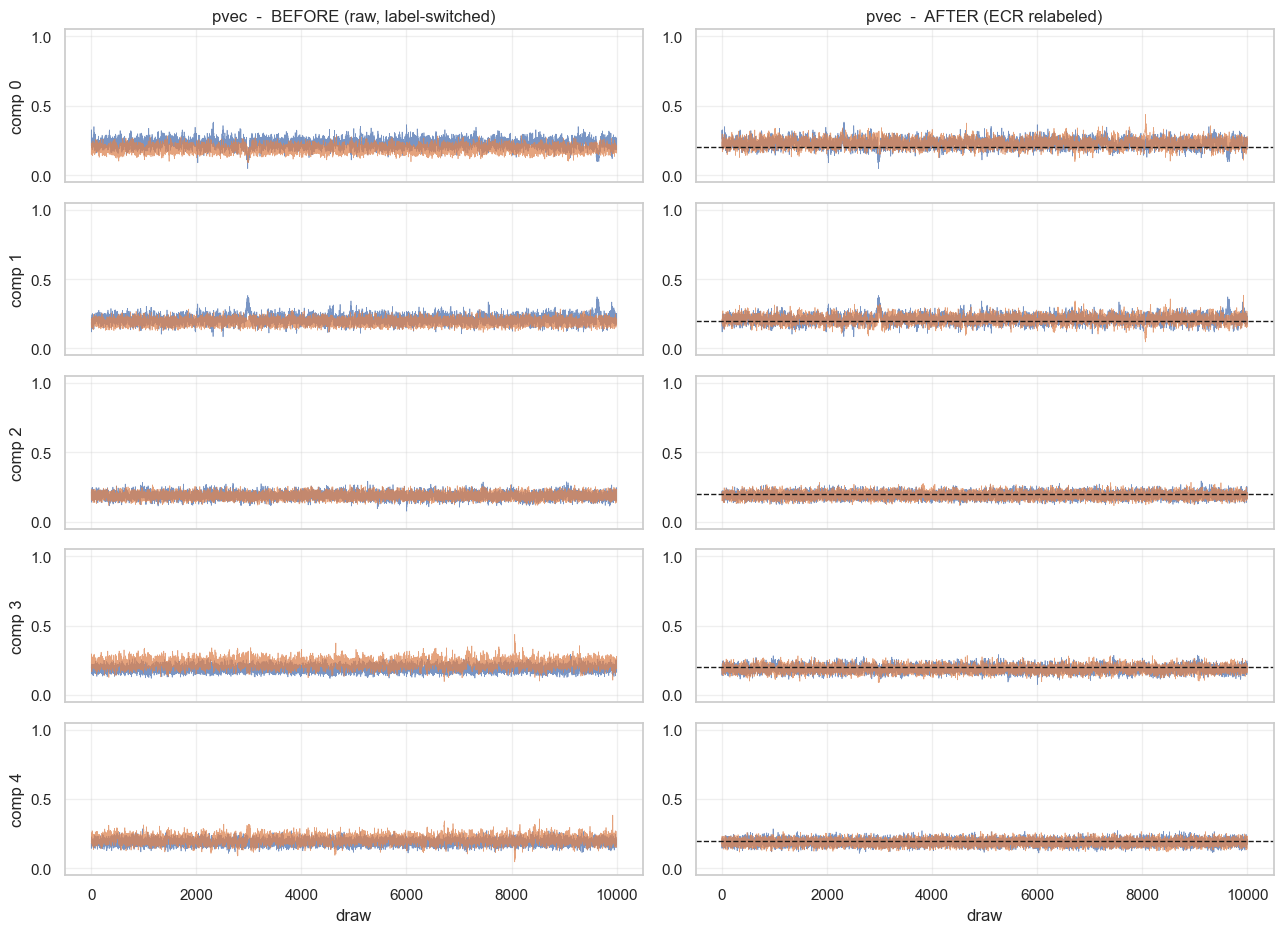

In [6]:
# ── Cell 6 : pvec - Full Before / After (ALL components) ──────────
pvec_before = np.asarray(analysis._recover_pvec(posterior_samples))   # (C,S,K)
pvec_after  = np.asarray(relabeled["pvec"])                           # (C,S,K)

# Mean weight per component, before vs after (all K slots).
mb = pvec_before.reshape(-1, K_MODEL).mean(0)
ma = pvec_after.reshape(-1, K_MODEL).mean(0)
print("Mean pvec per slot (before = label-switched -> smeared; after = ordered):")
display(pd.DataFrame({"mean_pvec_before": mb.round(3), "mean_pvec_after": ma.round(3)},
                     index=[f"slot {k}" for k in range(K_MODEL)]))

# R-hat / ESS for EVERY component (live = K_TRUE heaviest, flagged). For purely
# within-chain switching R-hat can already be ~1 - then ESS recovery is the signal.
print("Per-component R-hat / ESS - BEFORE:")
display(ls.component_convergence_table(posterior_samples, K_MODEL, K_TRUE,
        label="before", all_slots=True).set_index(["slot", "live", "quantity"]).round(3))
print("Per-component R-hat / ESS - AFTER:")
display(ls.component_convergence_table(relabeled, K_MODEL, K_TRUE,
        label="after", all_slots=True).set_index(["slot", "live", "quantity"]).round(3))

# Trace grid for EVERY pvec component, raw (before) vs relabeled (after).
# y-axis fixed to (-0.05, 1.05) to match the analysis notebook's pvec traces.
ls.plot_before_after_traces(pvec_before, pvec_after, K_MODEL, title="pvec",
                            true_vals=t_pvec, K_true=K_TRUE, ylim=(-0.05, 1.05))

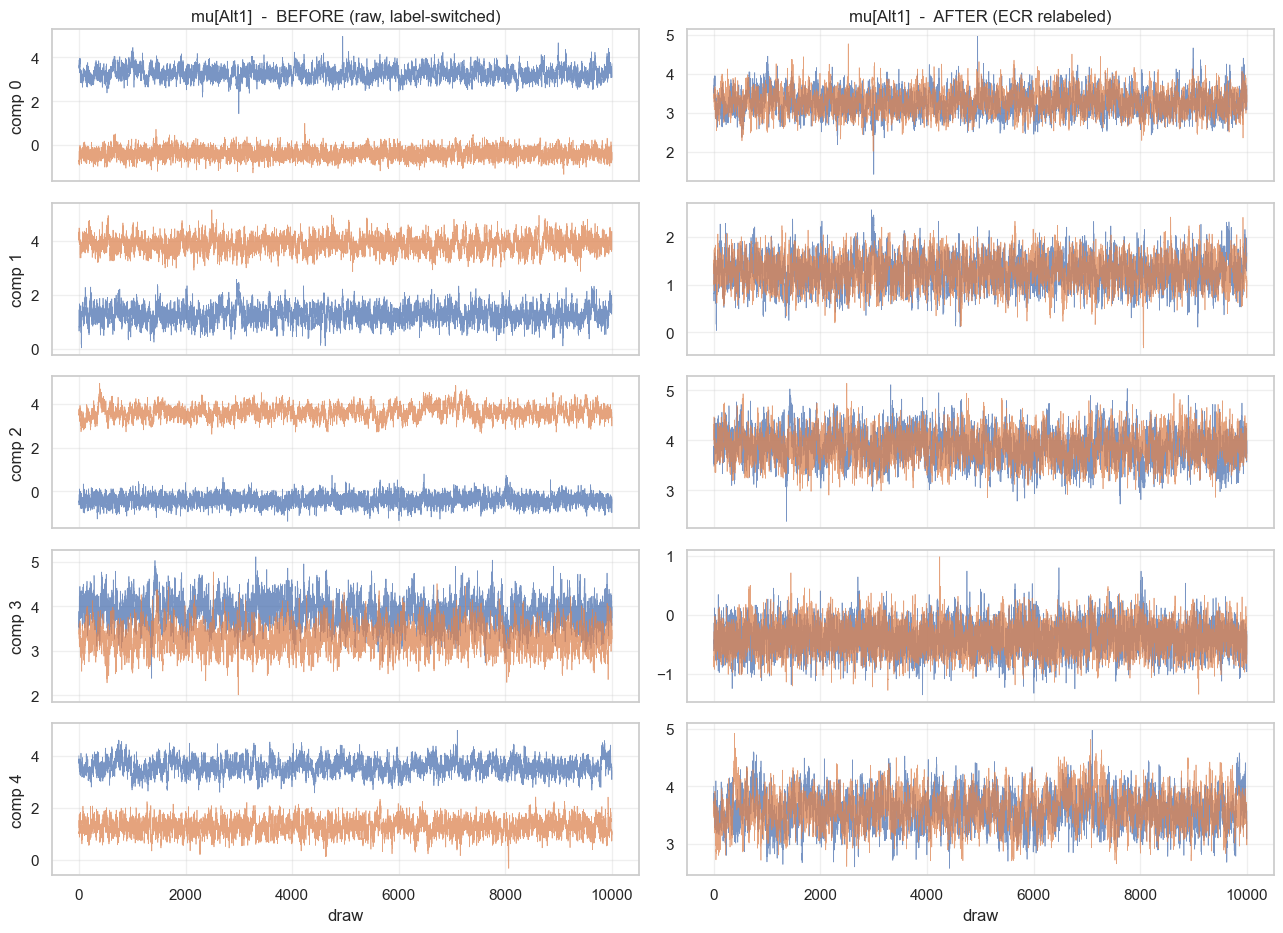

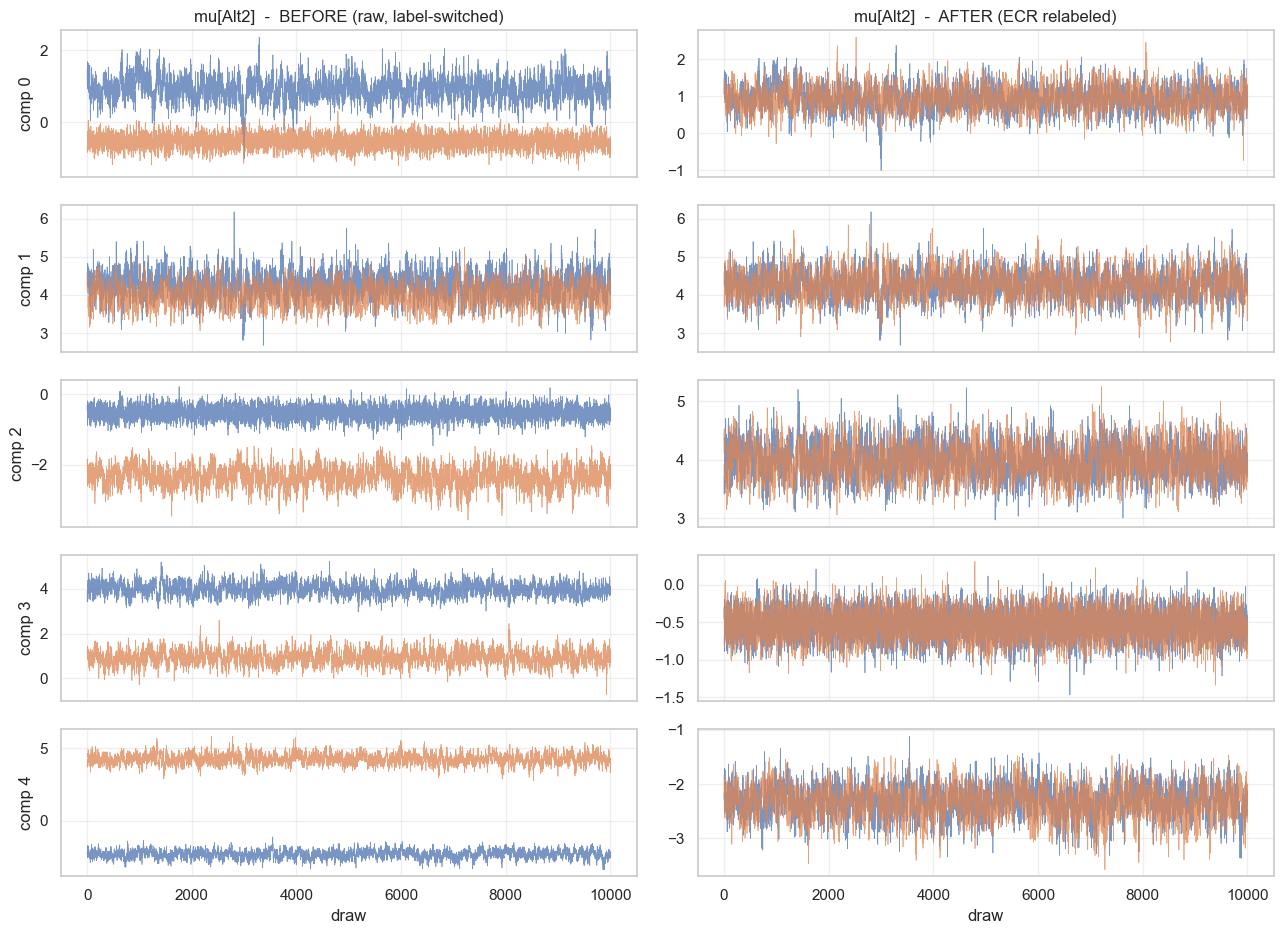

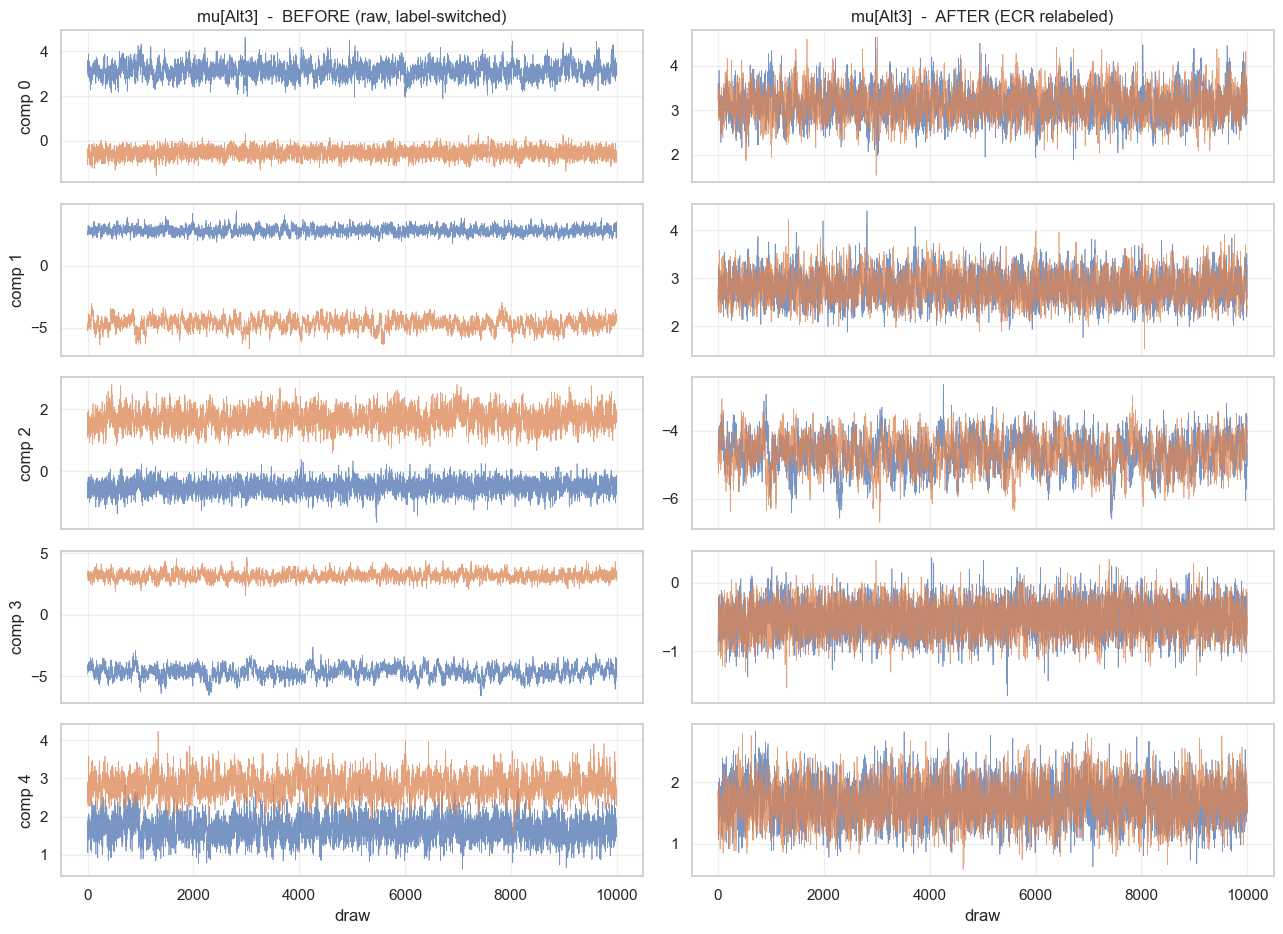

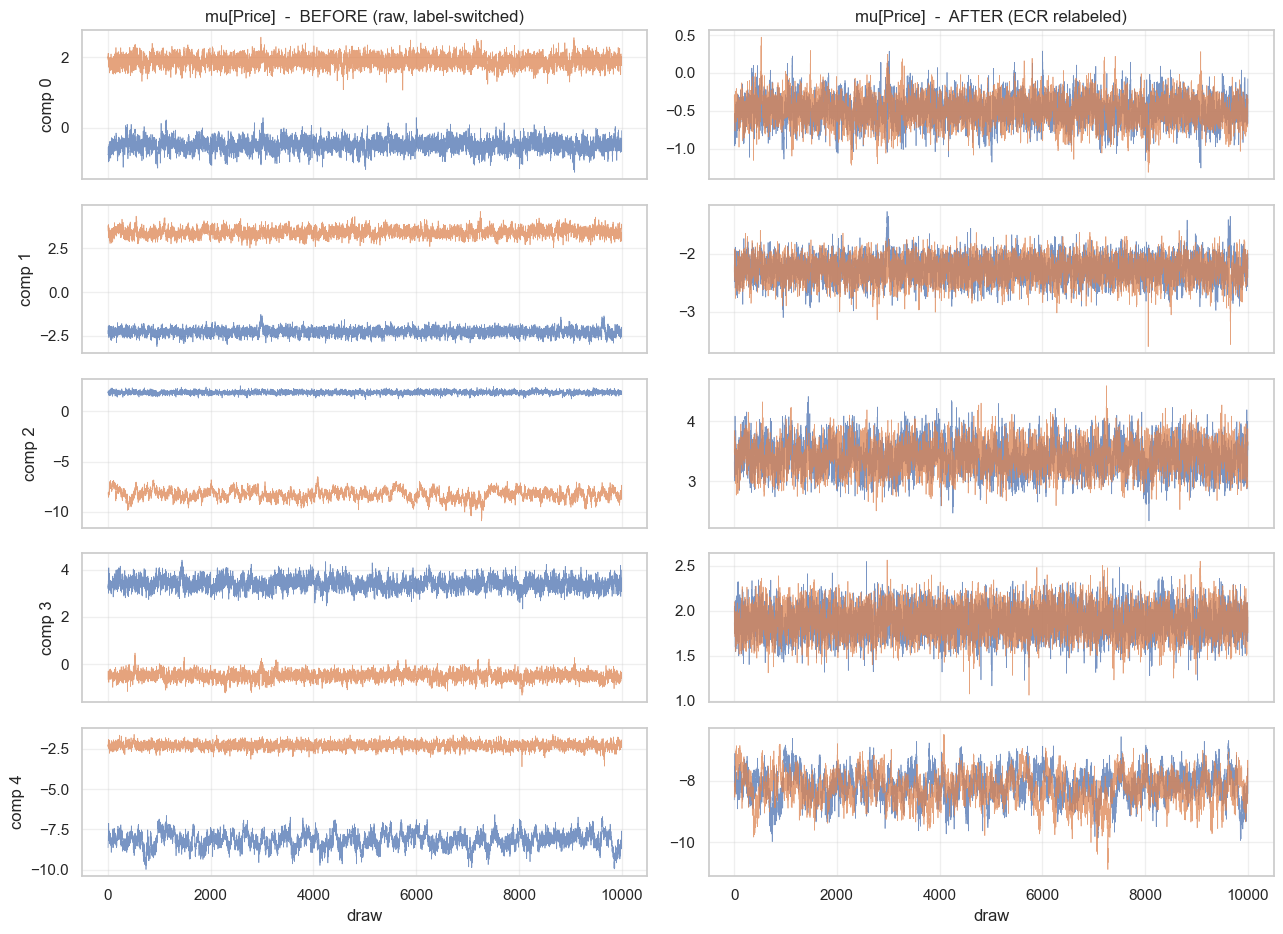

In [7]:
# ── Cell 7 : mu_k - Full Before / After (ALL components, ALL parameters) ──────────
mu_before = np.asarray(posterior_samples["mu_k"])   # (C,S,K,P)
mu_after  = np.asarray(relabeled["mu_k"])
# One trace grid per parameter; each shows every K component before vs after.
for p in range(P):
    ls.plot_before_after_traces(mu_before[:, :, :, p], mu_after[:, :, :, p], K_MODEL,
                                title=f"mu[{param_names[p]}]")

In [8]:
# ── Cell 8 : Cross-Chain Agreement, Recovery & Caveats ──────────
from scipy.optimize import linear_sum_assignment

live = report["live_slots"]   # the K_TRUE heaviest (live) slots

# Per-chain mean of mu[0] for ALL slots: if chains disagree slot-by-slot even
# AFTER relabeling, that is genuine multimodality, not a permutation artifact.
def _per_chain_table(samples):
    pcm = analysis.per_chain_mu_means(samples)
    return pd.DataFrame({ch: v[:, 0] for ch, v in pcm.items()},
                        index=[f"slot {k}" for k in range(K_MODEL)])
print("Per-chain mean of mu[0] per slot - BEFORE:")
display(_per_chain_table(posterior_samples).round(3))
print("AFTER (should agree slot-by-slot if switching was the only problem):")
display(_per_chain_table(relabeled).round(3))

ok = ls.invariance_guard(posterior_samples, relabeled)
print(f"\nInvariance guard (E[u] identical before/after): {ok}")
print("  (no-corruption check only: it passes for ANY consistent permutation, so")
print("   it does NOT by itself certify the relabeling is correct.)\n")

if t_mu is not None:
    rel_mu_mean   = np.asarray(relabeled["mu_k"]).reshape(-1, K_MODEL, P).mean(0)[live]
    rel_pvec_mean = np.asarray(relabeled["pvec"]).reshape(-1, K_MODEL).mean(0)[live]
    cost = ((rel_mu_mean[:, None, :] - t_mu[None, :, :]) ** 2).sum(-1)
    ri, ci = linear_sum_assignment(cost)
    rows = []
    for r, c in zip(ri, ci):
        rows.append({
            "live_slot":   int(live[r]),
            "matched_true": int(c),
            "pvec_post":   round(float(rel_pvec_mean[r]), 3),
            "pvec_true":   round(float(t_pvec[c]), 3) if t_pvec is not None else None,
            "mu_L2_err":   round(float(np.sqrt(((rel_mu_mean[r] - t_mu[c]) ** 2).sum())), 3),
        })
    print("Relabeled live-slot recovery vs ground truth (Hungarian-matched to truth):")
    display(pd.DataFrame(rows))

print("\nCAVEATS (per project methodology):")
print(" - Component-level recovery is ILLUSTRATIVE only; the load-bearing inference")
print("   is on the label-invariant functionals (marginal density, mixture moments).")
print(" - ECR aligns permutations WITHIN a mode; it cannot merge different partition")
print("   modes. If the invariant sorted-pvec R-hat (Cell 4) is high, the weight")
print("   posterior is multimodal - not a label artifact - and these per-component")
print("   summaries remain illustrative, not a recovery.")
print(" - Empty components (K_MODEL > K_TRUE) are unidentified and excluded above.")

# Persist the relabeled draws additively (never touches posterior_raw.pkl).
with open(RESULTS_DIR / "relabeled_posterior.pkl", "wb") as f:
    pickle.dump({k: np.asarray(v) for k, v in relabeled.items()}, f)
print(f"\nSaved relabeled draws -> {(RESULTS_DIR / 'relabeled_posterior.pkl')}")

Per-chain mean of mu[0] per slot - BEFORE:


,chain_0,chain_1
slot 0,3.273,-0.393
slot 1,1.270,3.876
slot 2,-0.390,3.606
slot 3,3.870,3.287
slot 4,3.578,1.279


AFTER (should agree slot-by-slot if switching was the only problem):


,chain_0,chain_1
slot 0,3.273,3.287
slot 1,1.270,1.279
slot 2,3.870,3.876
slot 3,-0.390,-0.393
slot 4,3.578,3.606



Invariance guard (E[u] identical before/after): True
  (no-corruption check only: it passes for ANY consistent permutation, so
   it does NOT by itself certify the relabeling is correct.)

Relabeled live-slot recovery vs ground truth (Hungarian-matched to truth):


,live_slot,matched_true,pvec_post,pvec_true,mu_L2_err
0,0,2,0.228,0.2,0.325
1,1,0,0.209,0.2,0.559
2,2,4,0.189,0.2,0.418
3,3,3,0.187,0.2,0.506
4,4,1,0.187,0.2,0.991



CAVEATS (per project methodology):
 - Component-level recovery is ILLUSTRATIVE only; the load-bearing inference
   is on the label-invariant functionals (marginal density, mixture moments).
 - ECR aligns permutations WITHIN a mode; it cannot merge different partition
   modes. If the invariant sorted-pvec R-hat (Cell 4) is high, the weight
   posterior is multimodal - not a label artifact - and these per-component
   summaries remain illustrative, not a recovery.
 - Empty components (K_MODEL > K_TRUE) are unidentified and excluded above.



Saved relabeled draws -> C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\hbmnl_mixture_experiments\2_chains\5_comp\replication\5comp_equal_K5_seed42\results\relabeled_posterior.pkl
